# 🎵 Music Recommender System Based on Content-Based Filtering with GloVe

**Notebook utama** — Menjalankan seluruh pipeline dari preprocessing hingga UI.

Modul yang digunakan:
- `config.py` — Konfigurasi path & parameter
- `preprocessing.py` — Load & merge dataset
- `models.py` — Load model, generate embeddings, evaluasi
- `evaluation.py` — K-Fold Cross Validation
- `visualization.py` — Visualisasi perbandingan model

---

## 📋 Tahap 1: Setup & Konfigurasi

In [1]:
import os
import sys

# Pastikan folder research ada di sys.path agar import modul .py bisa berjalan
BASE_PATH = r"G:\My Drive\FinalArc\research"
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)

# Import modul kita
from config import *
from preprocessing import load_and_merge_dataset
from models import run_model_pipeline
from visualization import plot_all_comparisons

print("✅ Semua modul berhasil di-import!")
print(f"📁 BASE_PATH: {BASE_PATH}")

✅ Semua modul berhasil di-import!
📁 BASE_PATH: G:\My Drive\FinalArc\research


## 📂 Tahap 2: Load & Preprocessing Dataset

Load 3 dataset → cleaning → merge menjadi 1 DataFrame.

In [2]:
merged_df, user_df = load_and_merge_dataset(save_merged=True)

print(f"\n📊 Preview Dataset:")
display(merged_df[['track_name', 'artist_name', 'genre', 'popularity']].head(10))

📂 LOADING & MERGING DATASET
✅ Spotify Features: 232,725 lagu
✅ Song Lyrics: 379,931 lirik
✅ User Top Tracks: 23,822,550 user

🧹 Cleaning metadata...
🔗 Merging lagu + lirik...

✅ Dataset final: 20,101 lagu dengan lirik
📊 Popularitas: 0 - 100
🎵 Kolom: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'clean_track', 'clean_artist', 'Lyric']
💾 Tersimpan di: G:\My Drive\FinalArc\research\dataset\merged_songs.csv

📊 Preview Dataset:


,track_name,artist_name,genre,popularity
0,7 rings,Ariana Grande,Dance,100
1,"break up with your girlfriend, i'm bored",Ariana Grande,Dance,99
2,Dancing With A Stranger (with Normani),Sam Smith,Pop,97
3,MIDDLE CHILD,J. Cole,Hip-Hop,96
4,Baila Baila Baila,Ozuna,Reggaeton,95
5,Going Bad (feat. Drake),Meek Mill,Hip-Hop,95
6,High Hopes,Panic! At The Disco,Pop,95
7,"thank u, next",Ariana Grande,Dance,95
8,Giant (with Rag'n'Bone Man),Calvin Harris,Dance,94
9,SAD!,XXXTENTACION,Hip-Hop,92


## 🤖 Tahap 3: Training & Evaluasi Model

Jalankan pipeline untuk ketiga model word embedding secara berurutan.

### 3.1 FastText

In [3]:
result_ft = run_model_pipeline('FastText', merged_df)

import pandas as pd
from IPython.display import display, HTML

# Tampilkan tabel per-fold (format sama dengan original)
print('\n' + '='*70)
print('📊 HASIL K-FOLD CROSS VALIDATION - FASTTEXT')
print('='*70)

print('\n📋 Tabel 1: Hasil Per Fold')
print('-'*70)
fold_df = pd.DataFrame(result_ft['results']['Fold Results'])
fold_df['Hit Rate (%)'] = fold_df['Hit Rate (%)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
fold_df['MRR'] = fold_df['MRR'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)
fold_df['NDCG'] = fold_df['NDCG'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)
display(fold_df)

# Ringkasan Metrik
print('\n📋 Tabel 2: Ringkasan Metrik Evaluasi')
print('-'*70)
r = result_ft['results']
summary = pd.DataFrame({
    'Metrik': ['Hit Rate', 'MRR (Mean Reciprocal Rank)', 'NDCG (Normalized DCG)'],
    'Nilai': [f"{r['Hit Rate']:.2%}", f"{r['MRR']:.4f}", f"{r['NDCG']:.4f}"],
    'Std Dev (±)': [f"{r['Hit Rate Std']:.2%}", f"{r['MRR Std']:.4f}", f"{r['NDCG Std']:.4f}"],
    'Interpretasi': [
        '% query yang mendapat ≥1 rekomendasi relevan',
        'Rata-rata posisi rekomendasi pertama yang relevan',
        'Kualitas ranking dengan bobot posisi'
    ]
})
display(summary)

# Konfigurasi Model
print('\n📋 Tabel 3: Konfigurasi Model FastText')
print('-'*70)
config_data = {
    'Parameter': ['Model', 'Training Method', 'Embedding Dimension', 'Embedding Weighting',
                  'K-Folds', 'Top-K', 'Related Genres', 'Total Songs'],
    'Nilai': ['FastText', 'pretrained', '300', 'TF-IDF Weighted',
              str(r['K-Folds']), str(r['Top-K']), 'Ya (Aktif)', str(len(merged_df))]
}
display(pd.DataFrame(config_data))

print('\n' + '='*70)
print('✅ Evaluasi FastText selesai!')
print('='*70)


🚀 PIPELINE: FastText
📂 Memuat FastText dari: G:\My Drive\FinalArc\research\saved_models\fasttext_wiki_news_300.kv
✅ FastText loaded! Vocabulary: 999,999 kata
📂 Embeddings ditemukan, loading...
✅ FastText Embeddings loaded: (20101, 300)
🗑️ Model FastText dihapus dari memori
✅ FAISS Index: 20101 vectors

📊 Mengevaluasi FastText...
   Menggunakan 5-Fold Cross Validation...
   Top-K: 20
   Related Genres: Ya


✅ FastText selesai!
   Hit Rate: 90.83%
   MRR: 0.4692
   NDCG: 0.5615

📊 HASIL K-FOLD CROSS VALIDATION - FASTTEXT

📋 Tabel 1: Hasil Per Fold
----------------------------------------------------------------------


,Fold,Hit Rate (%),MRR,NDCG,Test Samples
0,Fold 1,91.02,0.4652,0.5593,4021
1,Fold 2,91.14,0.4784,0.5676,4020
2,Fold 3,91.27,0.4688,0.5627,4020
3,Fold 4,90.27,0.4721,0.5628,4020
4,Fold 5,90.45,0.4613,0.5552,4020
5,📊 Rata-rata,90.83,0.4692,0.5615,3216
6,📈 Std Dev,0.40,0.0058,0.0041,-



📋 Tabel 2: Ringkasan Metrik Evaluasi
----------------------------------------------------------------------


,Metrik,Nilai,Std Dev (±),Interpretasi
0,Hit Rate,90.83%,0.40%,% query yang mendapat ≥1 rekomendasi relevan
1,MRR (Mean Reciprocal Rank),0.4692,0.0058,Rata-rata posisi rekomendasi pertama yang relevan
2,NDCG (Normalized DCG),0.5615,0.0041,Kualitas ranking dengan bobot posisi



📋 Tabel 3: Konfigurasi Model FastText
----------------------------------------------------------------------


,Parameter,Nilai
0,Model,FastText
1,Training Method,pretrained
2,Embedding Dimension,300
3,Embedding Weighting,TF-IDF Weighted
4,K-Folds,5
5,Top-K,20
6,Related Genres,Ya (Aktif)
7,Total Songs,20101



✅ Evaluasi FastText selesai!


### 3.2 GloVe ⭐ (Best Model)

In [4]:
result_glove = run_model_pipeline('GloVe', merged_df)

print('\n' + '='*70)
print('📊 HASIL K-FOLD CROSS VALIDATION - GLOVE')
print('='*70)

print('\n📋 Tabel 1: Hasil Per Fold')
print('-'*70)
fold_df = pd.DataFrame(result_glove['results']['Fold Results'])
fold_df['Hit Rate (%)'] = fold_df['Hit Rate (%)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
fold_df['MRR'] = fold_df['MRR'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)
fold_df['NDCG'] = fold_df['NDCG'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)
display(fold_df)

print('\n📋 Tabel 2: Ringkasan Metrik Evaluasi')
print('-'*70)
r = result_glove['results']
summary = pd.DataFrame({
    'Metrik': ['Hit Rate', 'MRR (Mean Reciprocal Rank)', 'NDCG (Normalized DCG)'],
    'Nilai': [f"{r['Hit Rate']:.2%}", f"{r['MRR']:.4f}", f"{r['NDCG']:.4f}"],
    'Std Dev (±)': [f"{r['Hit Rate Std']:.2%}", f"{r['MRR Std']:.4f}", f"{r['NDCG Std']:.4f}"],
    'Interpretasi': [
        '% query yang mendapat ≥1 rekomendasi relevan',
        'Rata-rata posisi rekomendasi pertama yang relevan',
        'Kualitas ranking dengan bobot posisi'
    ]
})
display(summary)

print('\n📋 Tabel 3: Konfigurasi Model GloVe')
print('-'*70)
config_data = {
    'Parameter': ['Model', 'Training Method', 'Embedding Dimension', 'Embedding Weighting',
                  'K-Folds', 'Top-K', 'Related Genres', 'Total Songs'],
    'Nilai': ['GloVe', 'pretrained', '300', 'TF-IDF Weighted',
              str(r['K-Folds']), str(r['Top-K']), 'Ya (Aktif)', str(len(merged_df))]
}
display(pd.DataFrame(config_data))

print('\n' + '='*70)
print('✅ Evaluasi GloVe selesai!')
print('='*70)


🚀 PIPELINE: GloVe
📂 Memuat GloVe dari: G:\My Drive\FinalArc\research\saved_models\glove_wiki_gigaword_300.kv
✅ GloVe loaded! Vocabulary: 400,000 kata
📂 Embeddings ditemukan, loading...
✅ GloVe Embeddings loaded: (20101, 300)
🗑️ Model GloVe dihapus dari memori
✅ FAISS Index: 20101 vectors

📊 Mengevaluasi GloVe...
   Menggunakan 5-Fold Cross Validation...
   Top-K: 20
   Related Genres: Ya


✅ GloVe selesai!
   Hit Rate: 92.65%
   MRR: 0.4886
   NDCG: 0.5792

📊 HASIL K-FOLD CROSS VALIDATION - GLOVE

📋 Tabel 1: Hasil Per Fold
----------------------------------------------------------------------


,Fold,Hit Rate (%),MRR,NDCG,Test Samples
0,Fold 1,93.01,0.4842,0.5770,4021
1,Fold 2,92.66,0.4973,0.5851,4020
2,Fold 3,93.46,0.4946,0.5838,4020
3,Fold 4,92.36,0.4923,0.5814,4020
4,Fold 5,91.77,0.4747,0.5689,4020
5,📊 Rata-rata,92.65,0.4886,0.5792,3216
6,📈 Std Dev,0.57,0.0082,0.0059,-



📋 Tabel 2: Ringkasan Metrik Evaluasi
----------------------------------------------------------------------


,Metrik,Nilai,Std Dev (±),Interpretasi
0,Hit Rate,92.65%,0.57%,% query yang mendapat ≥1 rekomendasi relevan
1,MRR (Mean Reciprocal Rank),0.4886,0.0082,Rata-rata posisi rekomendasi pertama yang relevan
2,NDCG (Normalized DCG),0.5792,0.0059,Kualitas ranking dengan bobot posisi



📋 Tabel 3: Konfigurasi Model GloVe
----------------------------------------------------------------------


,Parameter,Nilai
0,Model,GloVe
1,Training Method,pretrained
2,Embedding Dimension,300
3,Embedding Weighting,TF-IDF Weighted
4,K-Folds,5
5,Top-K,20
6,Related Genres,Ya (Aktif)
7,Total Songs,20101



✅ Evaluasi GloVe selesai!


### 3.3 Word2Vec

In [5]:
result_w2v = run_model_pipeline('Word2Vec', merged_df)

print('\n' + '='*70)
print('📊 HASIL K-FOLD CROSS VALIDATION - WORD2VEC')
print('='*70)

print('\n📋 Tabel 1: Hasil Per Fold')
print('-'*70)
fold_df = pd.DataFrame(result_w2v['results']['Fold Results'])
fold_df['Hit Rate (%)'] = fold_df['Hit Rate (%)'].apply(lambda x: f'{x:.2f}' if isinstance(x, float) else x)
fold_df['MRR'] = fold_df['MRR'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)
fold_df['NDCG'] = fold_df['NDCG'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)
display(fold_df)

print('\n📋 Tabel 2: Ringkasan Metrik Evaluasi')
print('-'*70)
r = result_w2v['results']
summary = pd.DataFrame({
    'Metrik': ['Hit Rate', 'MRR (Mean Reciprocal Rank)', 'NDCG (Normalized DCG)'],
    'Nilai': [f"{r['Hit Rate']:.2%}", f"{r['MRR']:.4f}", f"{r['NDCG']:.4f}"],
    'Std Dev (±)': [f"{r['Hit Rate Std']:.2%}", f"{r['MRR Std']:.4f}", f"{r['NDCG Std']:.4f}"],
})
display(summary)

config_data = {
    'Parameter': ['Model', 'Embedding Dim', 'Weighting', 'K-Folds', 'Top-K', 'Total Songs'],
    'Value': ['Word2Vec (word2vec-google-news-300)', '300', 'TF-IDF Weighted',
              str(r['K-Folds']), str(r['Top-K']), str(len(merged_df))]
}
display(pd.DataFrame(config_data))

print('\n' + '='*70)
print('✅ Evaluasi Word2Vec selesai!')
print('='*70)


🚀 PIPELINE: Word2Vec
📂 Memuat Word2Vec dari: G:\My Drive\FinalArc\research\saved_models\word2vec_google_news_300.kv
✅ Word2Vec loaded! Vocabulary: 3,000,000 kata
📂 Embeddings ditemukan, loading...
✅ Word2Vec Embeddings loaded: (20101, 300)
🗑️ Model Word2Vec dihapus dari memori
✅ FAISS Index: 20101 vectors

📊 Mengevaluasi Word2Vec...
   Menggunakan 5-Fold Cross Validation...
   Top-K: 20
   Related Genres: Ya


✅ Word2Vec selesai!
   Hit Rate: 90.44%
   MRR: 0.4701
   NDCG: 0.5606

📊 HASIL K-FOLD CROSS VALIDATION - WORD2VEC

📋 Tabel 1: Hasil Per Fold
----------------------------------------------------------------------


,Fold,Hit Rate (%),MRR,NDCG,Test Samples
0,Fold 1,90.75,0.4667,0.5617,4021
1,Fold 2,90.22,0.4812,0.5641,4020
2,Fold 3,91.49,0.4735,0.5654,4020
3,Fold 4,89.83,0.4699,0.5615,4020
4,Fold 5,89.90,0.4591,0.5505,4020
5,📊 Rata-rata,90.44,0.4701,0.5606,3216
6,📈 Std Dev,0.62,0.0073,0.0053,-



📋 Tabel 2: Ringkasan Metrik Evaluasi
----------------------------------------------------------------------


,Metrik,Nilai,Std Dev (±)
0,Hit Rate,90.44%,0.62%
1,MRR (Mean Reciprocal Rank),0.4701,0.0073
2,NDCG (Normalized DCG),0.5606,0.0053


,Parameter,Value
0,Model,Word2Vec (word2vec-google-news-300)
1,Embedding Dim,300
2,Weighting,TF-IDF Weighted
3,K-Folds,5
4,Top-K,20
5,Total Songs,20101



✅ Evaluasi Word2Vec selesai!


## 📊 Tahap 4: Visualisasi Perbandingan Model

Bar chart, radar chart, heatmap, dan per-fold performance.


📊 VISUALISASI PERBANDINGAN MODEL


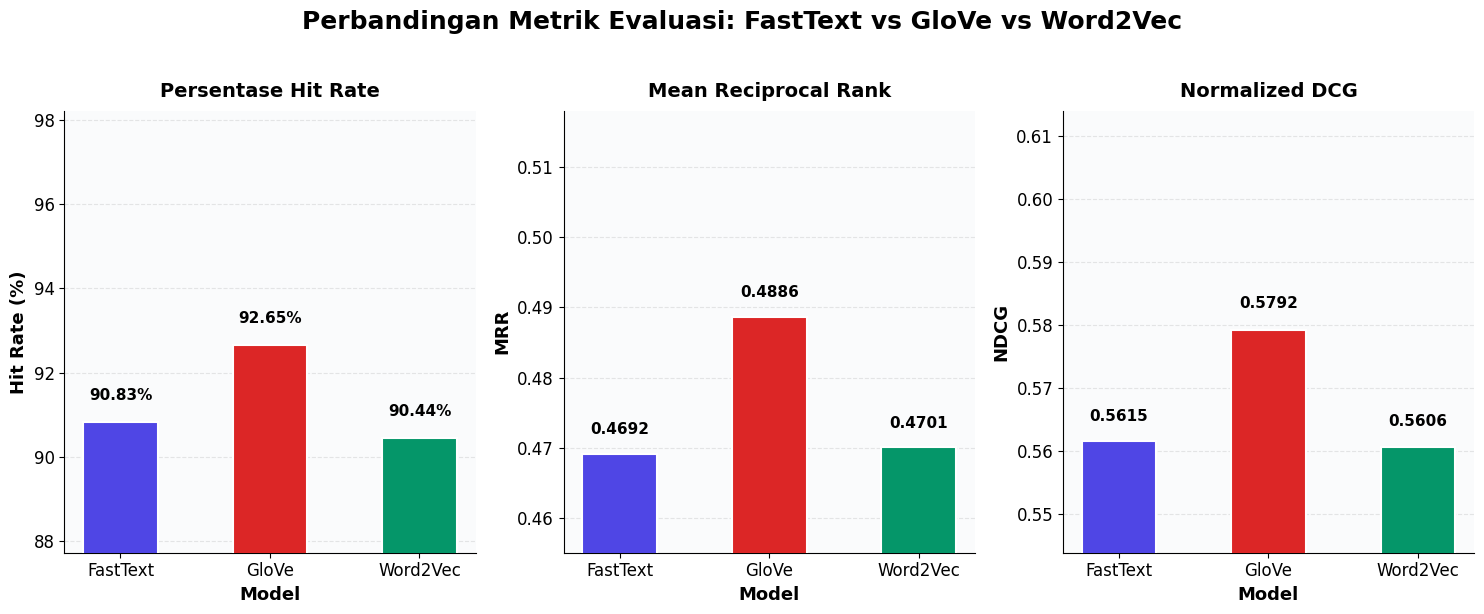

✅ Saved: G:\My Drive\FinalArc\research\visualisasi\comparison_bar_chart.png


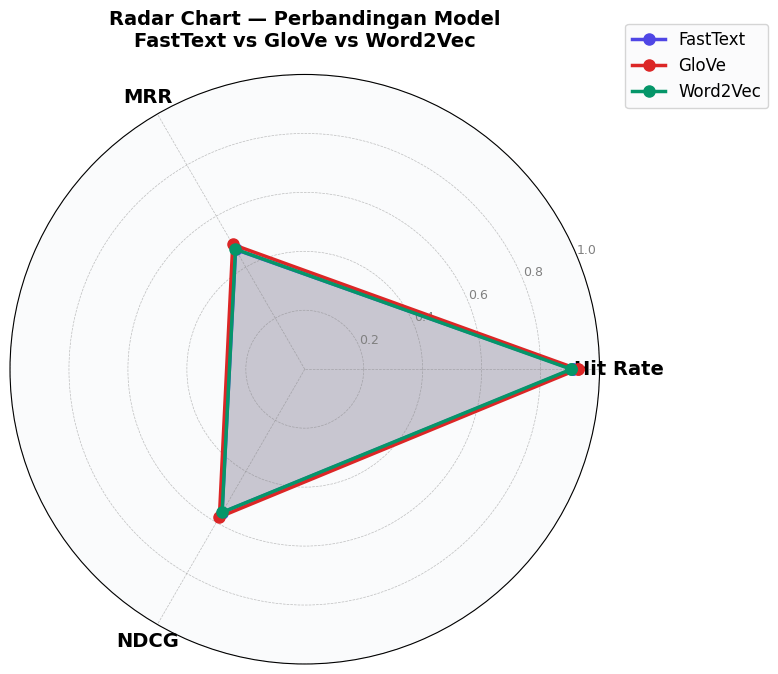

✅ Saved: G:\My Drive\FinalArc\research\visualisasi\comparison_radar_chart.png


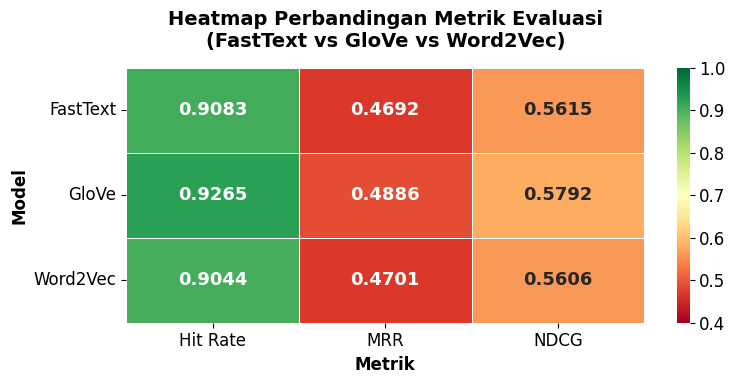

✅ Saved: G:\My Drive\FinalArc\research\visualisasi\comparison_heatmap.png


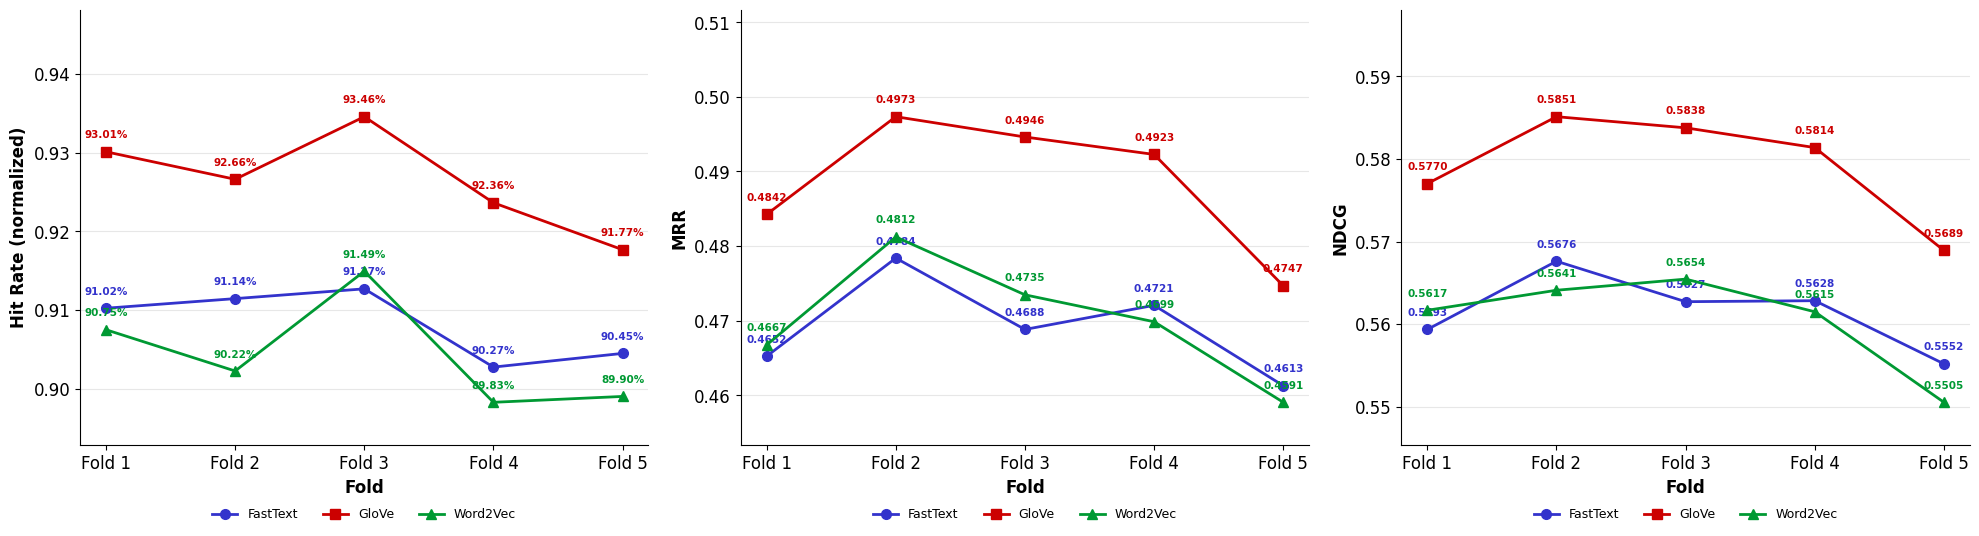

✅ Saved: G:\My Drive\FinalArc\research\visualisasi\per_fold_comparison_all_models.png


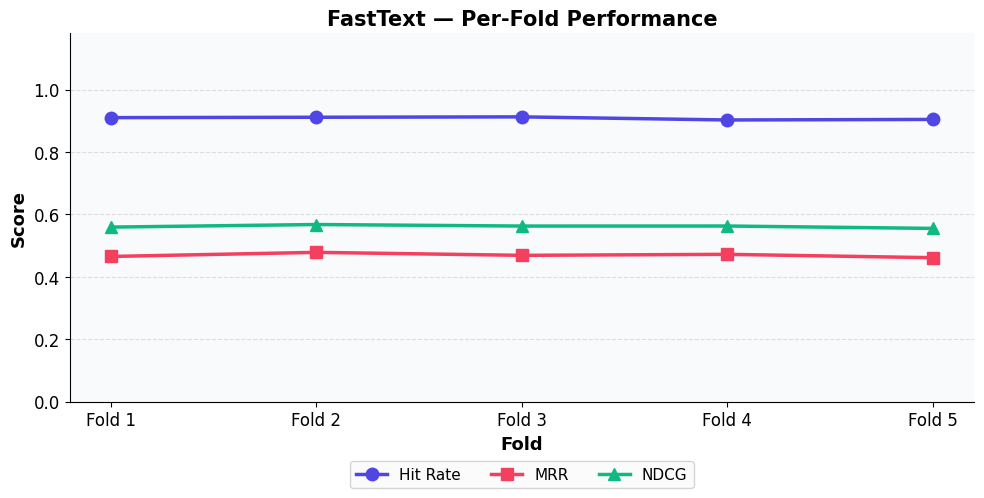

✅ Saved: G:\My Drive\FinalArc\research\visualisasi\fasttext_per_fold.png


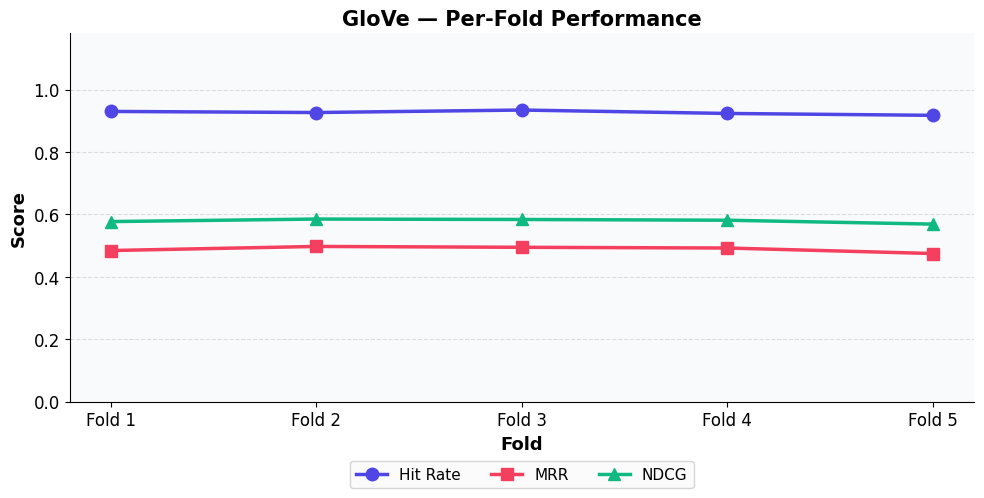

✅ Saved: G:\My Drive\FinalArc\research\visualisasi\glove_per_fold.png


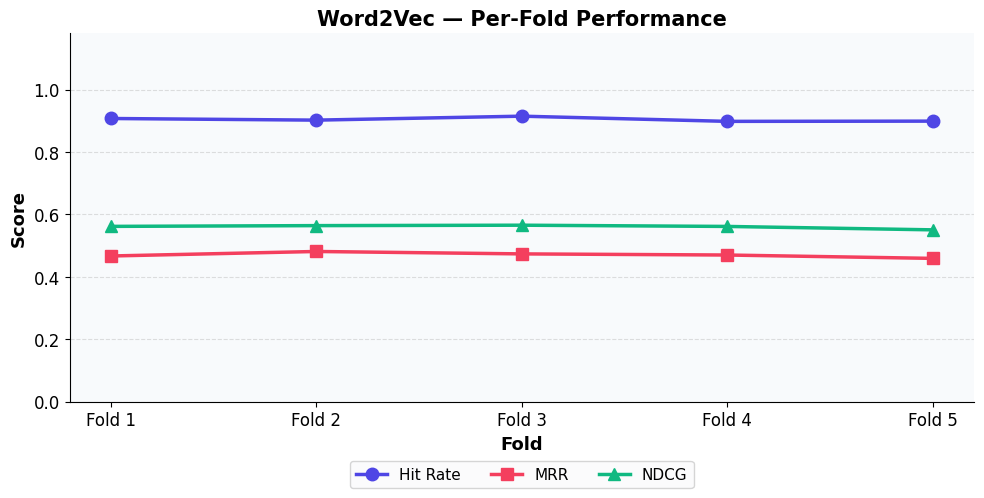

✅ Saved: G:\My Drive\FinalArc\research\visualisasi\word2vec_per_fold.png

✅ Semua visualisasi selesai dibuat!


In [6]:
# Reload modul agar perubahan terbaru di visualization.py terbaca
import importlib
import visualization
importlib.reload(visualization)
from visualization import plot_all_comparisons

all_results = {
    'FastText': result_ft,
    'GloVe': result_glove,
    'Word2Vec': result_w2v
}

plot_all_comparisons(all_results)

## 🏆 Tahap 5: Ringkasan Hasil

In [7]:
print("\n" + "="*70)
print("🏆 RINGKASAN HASIL EVALUASI")
print("="*70)

summary_data = []
for name in ['FastText', 'GloVe', 'Word2Vec']:
    r = all_results[name]['results']
    summary_data.append({
        'Model': name,
        'Hit Rate (%)': f"{r['Hit Rate']:.2%}",
        'MRR': f"{r['MRR']:.4f}",
        'NDCG': f"{r['NDCG']:.4f}",
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Tentukan model terbaik
best = max(all_results.items(), key=lambda x: x[1]['results']['NDCG'])
print(f"\n🏆 Model Terbaik: {best[0]}")
print(f"   Hit Rate: {best[1]['results']['Hit Rate']:.2%}")
print(f"   NDCG: {best[1]['results']['NDCG']:.4f}")


🏆 RINGKASAN HASIL EVALUASI


,Model,Hit Rate (%),MRR,NDCG
0,FastText,90.83%,0.4692,0.5615
1,GloVe,92.65%,0.4886,0.5792
2,Word2Vec,90.44%,0.4701,0.5606



🏆 Model Terbaik: GloVe
   Hit Rate: 92.65%
   NDCG: 0.5792


## 🎨 Tahap 6: UI Gradio — Demo Sistem Rekomendasi

Antarmuka interaktif untuk mendemonstrasikan sistem rekomendasi.

In [11]:
# Import module gradio_app
import importlib
import gradio_app
importlib.reload(gradio_app)

print("✅ Module gradio_app berhasil di-import!")

In [14]:
# Jalankan Gradio App UI
gradio_app.launch_gradio_app(merged_df, share=True)

## 🚀 Tahap 7: Deploy ke HuggingFace Space

Cell ini akan generate `app.py` yang sama persis dengan Gradio UI di atas, lalu push ke HuggingFace Space.

**Repo:** [faiqmisbah/musik-rekomendasi](https://huggingface.co/spaces/faiqmisbah/musik-rekomendasi)

In [ ]:
# Import module deploy
import importlib
import deploy
importlib.reload(deploy)

print("✅ Module deploy berhasil di-import!")

In [ ]:
# Jalankan otomatisasi konversi & deployment ke HuggingFace Space
deploy.deploy_to_huggingface(commit_message="Update app.py from main.ipynb via deploy.py")